In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1) Load your master CSV (must have columns 'filename' and 'level')
labels_df = pd.read_csv(r"G:\Graduation Project\Graduation-Project\labels\annotated_labels.csv")

# Make sure 'level' is a string (for flow_from_dataframe later)
labels_df['level'] = labels_df['level'].astype(str)

# 2) Stratified split: 75% train_val, 25% test_val
train_val_df, test_val_df = train_test_split(
    labels_df,
    test_size=0.25,
    stratify=labels_df['level'],
    random_state=42
)

# 3) Split that 25% evenly into val & test (each 12.5% of original)
val_df, test_df = train_test_split(
    test_val_df,
    test_size=0.5,
    stratify=test_val_df['level'],
    random_state=42
)

# 4) Build your custom TRAINING subset:
#    - Exactly 4000 samples of class '0'
#    - ALL samples of classes '1','2','3','4'

# how many class-0 you actually have
cnt0 = int((train_val_df['level']=='0').sum())

# do we need replacement?
replace_flag = cnt0 < 4000

class0_df = (
    train_val_df
    .loc[train_val_df['level']=='0']
    .sample(n=4000, replace=replace_flag, random_state=42)
)

# all other classes unchanged
others_df = train_val_df.loc[train_val_df['level']!='0']

# concatenate and shuffle
train_custom_df = (
    pd.concat([class0_df, others_df], axis=0)
      .sample(frac=1.0, random_state=42)
      .reset_index(drop=True)
)

train_custom_df['image'] = train_custom_df['image'].apply(lambda x: x + '.jpeg' if not x.endswith('.jpeg') else x)
train_custom_df.to_csv("train_labels_subset_fixed.csv", index=False)


# 5) Quick sanity check
print("→ Final training counts:")
print(train_custom_df['level'].value_counts())

print("\n→ Validation counts:")
print(val_df['level'].value_counts())

print("\n→ Test counts:")
print(test_df['level'].value_counts())


→ Final training counts:
level
0    4000
2    3969
1    1832
3     655
4     531
Name: count, dtype: int64

→ Validation counts:
level
0    3226
2     661
1     306
3     109
4      89
Name: count, dtype: int64

→ Test counts:
level
0    3227
2     662
1     305
3     109
4      88
Name: count, dtype: int64


## Preprocessing + Image generation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
from pathlib import Path


base_dir = Path().resolve()


Train_labels_path = base_dir.parent/ 'labels'/'train_labels_fixed.csv'
Test_labels_path = base_dir.parent/ 'labels'/'test_labels_fixed.csv'
Val_labels_path = base_dir.parent/ 'labels'/'val_labels_fixed.csv'

train_df = pd.read_csv(Train_labels_path)
train_df = train_df.rename(columns={'image': 'filename'})  # or whatever the original name is
train_df['class'] = train_df['level'].astype(str)

# train_custom_df = train_custom_df.rename(columns={'image': 'filename'})  # or whatever the original name is
# train_custom_df['class'] = train_custom_df['level'].astype(str)



validate_df = pd.read_csv(Val_labels_path)
validate_df = validate_df.rename(columns={'image': 'filename'})
validate_df['class'] = validate_df['level'].astype(str)

test_df = pd.read_csv(Test_labels_path)
test_df = test_df.rename(columns={'image': 'filename'})
test_df['class'] = test_df['level'].astype(str)

image_dir=base_dir.parent/'G:\Graduation Project\labled-images-cropped'

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)


train_data = train_gen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='filename',
    y_col='class',
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

val_data = val_gen.flow_from_dataframe(
    dataframe=validate_df,
    directory=image_dir,
    x_col='filename',
    y_col='class',
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)





Found 24475 validated image filenames belonging to 5 classes.


e:\Anaconda3\envs\new-env\lib\site-packages\keras\preprocessing\image.py:1139: UserWarning: Found 119 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


Found 6983 validated image filenames belonging to 5 classes.


e:\Anaconda3\envs\new-env\lib\site-packages\keras\preprocessing\image.py:1139: UserWarning: Found 36 invalid image filename(s) in x_col="filename". These filename(s) will be ignored.
  warnings.warn(


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers
from tensorflow_addons.metrics import CohenKappa
from sklearn.metrics import cohen_kappa_score


# Load ResNet50 base
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Freeze for warm-up

# Add custom top layers
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(5, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', CohenKappa(num_classes=5)]
)

warmup_epochs = 5
model.fit(
    train_data,
    validation_data=val_data,
    epochs=warmup_epochs
)

# Unfreeze the entire base model
base_model.trainable = True

# Re-compile with a lower learning rate
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', CohenKappa(num_classes=5)]
)

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint("resnet_trail_2.h5", save_best_only=True, monitor='val_accuracy', mode='max'),
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=3, min_lr=1e-7)
]

fine_tune_epochs = 35

model.fit(
    train_data,
    validation_data=val_data,
    epochs=fine_tune_epochs,
    callbacks=callbacks
)

# Get predictions from the model (softmax outputs)
y_pred = model.predict(val_data)

# Convert to predicted class labels (e.g., 0–4)
y_pred_labels = y_pred.argmax(axis=1)

# Get true class labels from the generator
y_true = val_data.classes

# Calculate Quadratic Weighted Kappa
qwk = cohen_kappa_score(y_true, y_pred_labels, weights='quadratic')
print(f"\n📊 Quadratic Weighted Kappa (QWK): {qwk:.4f}")


Epoch 1/5
765/765 [==============================] - 176s 227ms/step - loss: 1.0360 - accuracy: 0.6927 - cohen_kappa: 0.1134 - val_loss: 0.7774 - val_accuracy: 0.7451 - val_cohen_kappa: 0.1560
Epoch 2/5
765/765 [==============================] - 174s 228ms/step - loss: 0.7866 - accuracy: 0.7419 - cohen_kappa: 0.1479 - val_loss: 0.7618 - val_accuracy: 0.7470 - val_cohen_kappa: 0.1685
Epoch 3/5
765/765 [==============================] - 172s 225ms/step - loss: 0.7685 - accuracy: 0.7423 - cohen_kappa: 0.1494 - val_loss: 0.7535 - val_accuracy: 0.7515 - val_cohen_kappa: 0.1473
Epoch 4/5
765/765 [==============================] - 173s 226ms/step - loss: 0.7636 - accuracy: 0.7449 - cohen_kappa: 0.1660 - val_loss: 0.7608 - val_accuracy: 0.7487 - val_cohen_kappa: 0.1733
Epoch 5/5
765/765 [==============================] - 172s 225ms/step - loss: 0.7567 - accuracy: 0.7477 - cohen_kappa: 0.1775 - val_loss: 0.7467 - val_accuracy: 0.7501 - val_cohen_kappa: 0.1396
Epoch 1/50
765/765 [===============

219/219 [==============================] - 19s 86ms/step

📊 Quadratic Weighted Kappa (QWK): 0.5945

📋 Classification Report:
              precision    recall  f1-score   support

           0     0.8174    0.9668    0.8858      5145
           1     0.1429    0.0108    0.0200       464
           2     0.5647    0.3438    0.4274      1053
           3     0.5600    0.3256    0.4118       172
           4     0.6393    0.5235    0.5756       149

    accuracy                         0.7840      6983
   macro avg     0.5449    0.4341    0.4641      6983
weighted avg     0.7244    0.7840    0.7409      6983



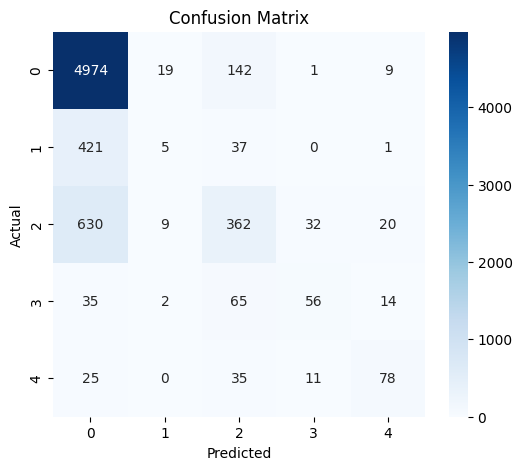

In [52]:
# ─── At the top of your file, alongside your other imports ───
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# ─── After your final `model.fit(...)` ───

# 1) Get softmax predictions on your validation data
y_pred = model.predict(val_data)
y_pred_labels = y_pred.argmax(axis=1)

# 2) Extract the true labels
y_true = val_data.classes

# 3) Compute Quadratic Weighted Kappa
qwk = cohen_kappa_score(y_true, y_pred_labels, weights='quadratic')
print(f"\n📊 Quadratic Weighted Kappa (QWK): {qwk:.4f}\n")

# 4) Print a full classification report
print("📋 Classification Report:")
print(classification_report(y_true, y_pred_labels, digits=4))

# 5) Plot the confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [27]:
class_counts = train_df['level'].value_counts()
print(class_counts)

level
0    18067
2     3692
1     1731
3      622
4      482
Name: count, dtype: int64
